# Single cell disease relevance scores on meta cells 

In [11]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
import glob                  # File pattern matching
from pyhere import here      # Reproducible project paths
import gc

# dataframes
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt

# scanpy
import scanpy as sc

# GWAS
import gwaslab as gl

# Bash code 
import subprocess

sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import misc as mi

In [2]:
mi.create_directories(dir_path = str(here('data/scdrs/files')))
mi.create_directories(dir_path = str(here('data/scdrs/plots')))
mi.create_directories(dir_path = str(here('data/scdrs/objects')))
mi.create_directories(dir_path = str(here('data/scdrs/reference')))
mi.create_directories(dir_path = str(here('data/scdrs/sumstats_processed')))
mi.create_directories(dir_path = str(here('data/scdrs/sumstats_annotated')))

/work/islet_cartography_scrna/data/scdrs/files Directory already exists!
/work/islet_cartography_scrna/data/scdrs/plots Directory already exists!
/work/islet_cartography_scrna/data/scdrs/objects Directory already exists!
/work/islet_cartography_scrna/data/scdrs/reference Directory already exists!
/work/islet_cartography_scrna/data/scdrs/sumstats_processed Directory already exists!
/work/islet_cartography_scrna/data/scdrs/sumstats_annotated Directory already exists!


In [3]:
base_dir = str(here("data/scdrs"))
reference =  os.path.join(base_dir, "reference")
files_dir =  os.path.join(base_dir, "files")
sumsp_dir = os.path.join(base_dir, "sumstats_processed")
sumsa_dir = os.path.join(base_dir, "sumstats_annotated")

#### Download reference data

In [ ]:
# hg19 (GRCh37): 
gl.download_ref("1kg_dbsnp151_hg19_auto", directory=reference)
#hg38 (GRCh38): 
gl.download_ref("1kg_dbsnp151_hg38_auto", directory=reference)

Gene and reference location files were downloaded from: https://cncr.nl/research/magma/ (access: 2025-12-19)

#### Downlad and preprocess sumstat files

In this step we processes GWAS (genome-wide association study) summary statistics for multiple traits. 
For each trait listed in a manifest file, it:

- Downloads the raw GWAS summary statistics file from a URL, verifying the file integrity with an md5 checksum
- Cleans and standardizes the summary stats using the gwaslab library: this includes basic QC, lifting over coordinates to the same genome build (hg19) if needed, and assigning rsIDs to SNPs
- Runs MAGMA (a gene-level analysis tool) in two steps:
  - First annotating which SNPs belong to which genes, by looking 35 kb upstream and 10 kb downstream of a gene.
  - Then computing gene-level association statistics from the SNP p-values.
- Adds gene symbols to the MAGMA output (MAGMA only outputs numeric gene IDs by default)
- Cleans up temporary files if all expected output files were successfully created
- Hereafter we extract p-value and z-scores for each SNP, so that they are ready for generating the geneset files

The end result is a set of annotated gene-level association files for each trait

In [ ]:
# ----------------------------- USER CONFIG -----------------------------------
# Work and reference directory
wd         = "/work/islet_cartography_scrna"
tmp_dir    = f"{wd}/tmp"
ref_dir    = f"{wd}/data/scdrs/ref_magma"
reference_dir = f"{wd}/data/scdrs/reference"

# Program paths
magma_prog = f"{wd}/MAGMA/magma"
aria2c = f"{wd}/scrna_cartography_gwas/bin/aria2c"

# File dir
gwas_dir   = f"{wd}/data/scdrs"
file_dir   = f"{gwas_dir}/files"
out_dir    = f"{gwas_dir}/sumstats_annotated"
pz_dir = f"{gwas_dir}/pval_zscore"

process_file = f"{file_dir}/gwas_process_file.txt"

os.makedirs(tmp_dir, exist_ok=True)
os.makedirs(pz_dir, exist_ok=True)
os.chdir(tmp_dir)

# ----------------------------- LOAD MANIFEST ---------------------------------
manifest = pd.read_csv(process_file, sep="\t")
# ----------------------------- LOOP ------------------------------------------
for _, trait in manifest.iterrows():
    z              = trait["name"]
    file_name      = trait["name_save"]
    n              = int(trait["sample_size"])
    genome_version = trait["genome_original"]
    ref_bim        = trait["genome_reference"]
    gene_loc       = trait["gene_annotation_reference"]
    url            = trait["sumstats_file"] 
    md5            = trait["md5sum"]
    out_prefix     = f"{out_dir}/{z}"
    
    if os.path.isfile(f"{out_prefix}.symbol.out"):
        print(f"{z} has already been processed, skipping...")
        continue

    print(f"\n--- Processing: {z} ---")

    # ----------------------------- DOWNLOAD ----------------------------------
    print(f"Downloading {z}")
    download_input = f"{url}\n  out={file_name}\n  checksum=md5={md5}\n"
    with open("download", "w") as f:
        f.write(download_input)

    subprocess.run(
        [aria2c, "-i", "download", "-j", "10", "--check-integrity=true",
         "--save-session=failed.downloads"],
        check=True
    )

    # ----------------------------- GWASLAB -----------------------------------
    print(f"Annotating SNPs for {z}")
    build = "19" if genome_version == "GRCh37" else "38"

    ss = gl.Sumstats(file_name, n=n, build=build, sep="\t", fmt="ssf", verbose=False)
    ss.basic_check(verbose=False)

    # liftover if needed
    if build == "38":
        ss.liftover(from_build="38", to_build="19", remove=True)

    # Check SNPID column - if SNPID is there and they start with rs there is no need to assign rsids
    do_assign = True
    if "SNPID" in ss.data.columns:
        vals = ss.data["SNPID"].astype(str).head(50)
        if vals.str.startswith("rs").any():
            ss.data = ss.data.rename(columns={"SNPID": "rsID"})
            do_assign = False

    # Annotate if needed
    if do_assign:
        ss.assign_rsid(
            ref_rsid_tsv=gl.get_path("1kg_dbsnp151_hg19_auto"),
            threads=30,
            verbose=False
        )

    ss.data = ss.data[ss.data["rsID"].notna()]
    ss.data = ss.data.rename(columns={"rsID": "SNP"})

    if "P" not in ss.data.columns:
        ss.fill_data(to_fill=["P"])

    pval_file = f"{z}.pval"
    ss.data.to_csv(pval_file, sep="\t", index=False)

    del ss
    gc.collect()
    # ----------------------------- MAGMA -------------------------------------
    print(f"Running MAGMA for {z}")
    ref_prefix = ref_bim.replace(".bim", "")

    # Annotate genes with magma
    # Only needs to be run once per reference build / window size
    # Output: {annot_prefix}.genes.annot

    annot_prefix = f"{reference_dir}/hg19_w35_10" 
    
    if not os.path.isfile(f"{annot_prefix}.genes.annot"):
        print("Running MAGMA annotation (one-time step)...")
        subprocess.run([
            magma_prog, "--annotate", "window=35,10",
            "--snp-loc", f"{ref_dir}/{ref_bim}",
            "--gene-loc", f"{ref_dir}/{gene_loc}",
            "--out", annot_prefix
        ], check=True)
    else:
        print("Annotation file already exists, skipping...")
    
    # Gene analysis step — uses the shared annotation file
    # Gene analysis on SNP p-values
    subprocess.run([
        magma_prog, "--bfile", f"{ref_dir}/{ref_prefix}",
        "--pval", pval_file, "use=SNP,P", "ncol=N",
        "--gene-annot", f"{annot_prefix}.genes.annot",  
        "--out", out_prefix
    ], check=True)

    # ----------------------------- ADD SYMBOL --------------------------------
    print("Adding gene symbols")
    gene_ref = pd.read_csv(f"{ref_dir}/{gene_loc}", sep="\t", header=None)
    gene_map = dict(zip(gene_ref[0], gene_ref[5]))  # gene ID -> symbol

    genes_out = pd.read_csv(f"{out_prefix}.genes.out", sep=r"\s+")
    genes_out["SYMBOL"] = genes_out.iloc[:, 0].map(gene_map).fillna("NA")
    genes_out.to_csv(f"{out_prefix}.symbol.out", sep="\t", index=False)

    del gene_ref
    del gene_map
    del genes_out
    gc.collect()
    
    # ----------------------------- CLEANUP -----------------------------------
    result_files = [
        f"{out_prefix}.genes.out",
        f"{out_prefix}.symbol.out",
        f"{out_prefix}.genes.raw",
        f"{out_prefix}.log.suppl"
    ]

    if all(os.path.isfile(f) for f in result_files):
        for pattern in ["trait", "download", "failed.downloads"]:
            if os.path.exists(pattern):
                os.remove(pattern)
        for f in os.listdir(tmp_dir):
            if f.endswith((".tsv.gz", ".pval")):
                os.remove(os.path.join(tmp_dir, f))
        for f in os.listdir(tmp_dir):
            if f.endswith(".log"):
                os.rename(os.path.join(tmp_dir, f), os.path.join(out_dir, f))
        print(f"Finished {z} — output in {out_prefix}")
    else:
        print(f"Warning: some output files missing for {z}, skipping cleanup")

# ---- Collect P and ZSTAT across all traits into combined matrices-------
print("\n--- Collecting pval and zstat matrices ---")
pval_dfs = []
zstat_dfs = []

for filepath in glob.glob(f"{out_dir}/*.symbol.out"):
    file_name = os.path.basename(filepath).replace(".symbol.out", "")
    df = pd.read_csv(filepath, sep=r"\s+")

    pval_dfs.append(df[["SYMBOL", "P"]].rename(columns={"P": file_name}).set_index("SYMBOL"))
    zstat_dfs.append(df[["SYMBOL", "ZSTAT"]].rename(columns={"ZSTAT": file_name}).set_index("SYMBOL"))

pd.concat(pval_dfs, axis=1, join="outer").to_csv(
    os.path.join(pz_dir, "pval.tsv"), sep="\t", na_rep="NA"
)
print("pval.tsv done")

pd.concat(zstat_dfs, axis=1, join="outer").to_csv(
    os.path.join(pz_dir, "zstat.tsv"), sep="\t", na_rep="NA"
)
print("zstat.tsv done")

# ----------------------------- CLEANUP ---------------------------------------
result_files = [os.path.join(pz_dir, "pval.tsv"), os.path.join(pz_dir, "zstat.tsv")]
if all(os.path.isfile(f) for f in result_files):
    for f in glob.glob(f"{tmp_dir}/*.tsv"):
        os.remove(f)
    print(f"Finished! Final output files are in {pz_dir}")
else:
    print("Warning: one or more output files are missing, skipping cleanup")

#### Prepare genesets for scdrs

In [ ]:
# ----------------------------- USER CONFIG -----------------------------------
# Work and reference directory
wd           = "/work/islet_cartography_scrna"
# Program paths
scdrs_bin    = f"{wd}/scrna_cartography_gwas/bin/scdrs"

# File dir
pz_dir       = f"{gwas_dir}/pval_zscore"
gs_dir       = f"{gwas_dir}/gs_files"
process_file = f"{file_dir}/gwas_process_file.txt"

os.makedirs(gs_dir, exist_ok=True)
# ----------------------------- MUNGE -----------------------------------------
print(f"Selecting top 1000 genes using z-scores")

try:
    result = subprocess.run([
        scdrs_bin, "munge_gs", 
        "--out-file", f"{gs_dir}/all_traits_geneset.gs",
        "--zscore-file", f"{pz_dir}/zstat.tsv",
        "--fdr", "0.1",
        "--n-max", "1000",
    ], capture_output=True, text=True, check=True)
    
    print(f"Finished Selecting top 1000 genes using z-scores")
    print(result.stdout)
    
except subprocess.CalledProcessError as e:
    print(f"Command failed with exit code {e.returncode}")
    print(f"\nSTDOUT:\n{e.stdout}")
    print(f"\nSTDERR:\n{e.stderr}")
    print(f"\nCommand: {' '.join(e.args)}")

#### Disease enrichment scores per meta cell

First column: cell names, should be the same as adata.obs_names.

raw_score: raw disease score.

norm_score: normalized disease score.

mc_pval: cell-level MC p-value. Raw p-value without multiple testing adjustment.

pval: cell-level scDRS p-value. Raw p-value without multiple testing adjustment.

nlog10_pval: -log10(pval).

zscore: z-score converted from pval.

ctrl_raw_score_<i_ctrl> : raw control scores, specified by --flag_return_ctrl_raw_score True.

ctrl_norm_score_<i_ctrl> : normalized control scores, specified by --flag_return_ctrl_norm_score True.

In [99]:
##  I added Gabijas T1D and T2D genesets to be tested as well
# ----------------------------- USER CONFIG -----------------------------------
# Work and reference directory
wd           = "/work/islet_cartography_scrna"
# Program paths
scdrs_bin    = f"{wd}/scrna_cartography_gwas/bin/scdrs"
h5ad_meta    = f"{wd}/data/meta_cell/objects/metacells_final.h5ad"
gs_file      = f"{wd}/data/scdrs/gs_files/all_traits_geneset_w_gabija_data.gs"
cov_file     = f"{wd}/data/meta_cell/files/metacell_cov.tsv"
out_dir      = f"{wd}/data/scdrs/scdrs_metacell_results"

os.makedirs(out_dir, exist_ok=True)
# ----------------------------- COMPUTE SCORES --------------------------------
print(f"Computing scores")

try:
    result = subprocess.run([
        scdrs_bin, "compute-score", 
        "--h5ad-file", h5ad_meta,
        "--h5ad-species", "human",
        "--gs-file", gs_file,
        "--gs-species", "human",
        "--cov-file", cov_file,
        "--flag-filter-data", "True",
        "--flag-raw-count", "True",
        "--n-ctrl", "1000",
        "--out-folder", out_dir 
    ], capture_output=True, text=True, check=True)
    
    print(f"Finished computing scores")
    print(result.stdout)
    
except subprocess.CalledProcessError as e:
    print(f"Command failed with exit code {e.returncode}")
    print(f"\nSTDOUT:\n{e.stdout}")
    print(f"\nSTDERR:\n{e.stderr}")
    # Use the actual command list instead of e.args
    print(f"\nCommand: {' '.join(str(arg) for arg in e.cmd)}")

Computing scores
Finished computing scores
******************************************************************************
* Single-cell disease relevance score (scDRS)
* Version 1.0.2
* Martin Jinye Zhang and Kangcheng Hou
* HSPH / Broad Institute / UCLA
* MIT License
******************************************************************************
Call: scdrs compute-score \
--h5ad-file /work/islet_cartography_scrna/data/meta_cell/objects/metacells_final.h5ad \
--h5ad-species human \
--cov-file /work/islet_cartography_scrna/data/meta_cell/files/metacell_cov.tsv \
--gs-file /work/islet_cartography_scrna/data/scdrs/gs_files/all_traits_geneset_w_gabija_data.gs \
--gs-species human \
--ctrl-match-opt mean_var \
--weight-opt vs \
--adj-prop None \
--flag-filter-data True \
--flag-raw-count True \
--n-ctrl 1000 \
--flag-return-ctrl-raw-score False \
--flag-return-ctrl-norm-score True \
--out-folder /work/islet_cartography_scrna/data/scdrs/scdrs_metacell_results

Loading data:
--h5ad-file loade

#### Downstream analysis
#https://martinjzhang.github.io/scDRS/file_format.html#trait-scdrs-group-annot
For a given cell group-level annotation (e.g., tissue or cell type), assess cell group-disease association (control-score-based MC tests using 5% quantile) and within-cell group disease-association heterogeneity (control-score-based MC tests using Geary’s C).

#### Group level
For each annotation within the group and for each group of cell in the annotation, this function calculates:
The proportion of cells that has an significant association with the trait (FDR less than 0.05, 0.1 or 0.2)
The group level trait assocaition
The gorup level heterogenity (Here is uses the connectivity generated when finding neighbors)

MC = Monte Carlo
n_cell: number of cells from the cell group.

n_ctrl: number of control gene sets.

assoc_mcp: MC p-value for cell group-disease association. Raw p-value without multiple testing adjustment.

assoc_mcz: MC z-score for cell group-disease association.

hetero_mcp: MC p-value for within-cell group heterogeneity in association with disease. Raw p-value without multiple testing adjustment.

hetero_mcz: MC z-score for within-cell group heterogeneity in association with disease.

['blood_insulin_level',
 'bmi',
 'body_fat_percentage',
 'glucagon_measurement',
 'hair_colour',
 'handedness',
 'hba1c',
 'heart_failure',
 'ins_protein_level',
 'ischemic_stroke',
 't2d',
 't2d_nephropathy',
 'waist_cir',
 'DIAMANTE_T2D',
 'T1D_Forgetta']

In [106]:
# Work and reference directory
wd           = "/work/islet_cartography_scrna"
# Program paths
scdrs_bin    = f"{wd}/scrna_cartography_gwas/bin/scdrs"
h5ad_meta    = f"{wd}/data/meta_cell/objects/metacells_final.h5ad"
results_dir   = f"{wd}/data/scdrs/scdrs_metacell_results"
out_dir      = f"{wd}/data/scdrs/scdrs_metacell_results"

traits = pd.read_csv("/work/islet_cartography_scrna/data/scdrs/gs_files/all_traits_geneset_w_gabija_data.gs", sep = "	")['TRAIT'].tolist()
traits = [ 'DIAMANTE_T2D', 'T1D_Forgetta']
groups = ['cell_type', 'cell_type_disease', 'cell_type_ethnicity']
for group in groups:
    for trait in traits:
        print(f"Attempting {trait} for {group}")
        cmd = [
            scdrs_bin, "perform-downstream",
            "--h5ad-file", h5ad_meta,
            "--score-file", f"{results_dir}/{trait}.full_score.gz",
            "--out-folder", results_dir + "/",
            "--group-analysis", f"{group}",
            "--flag-filter-data", "True",
            "--flag-raw-count", "True"
        ]
    
        result = subprocess.run(cmd,capture_output=True, text=True, check=True)
        if result.returncode == 0:
            print(f"Success for {trait}!")
        else:
            print(f"Still failing for {trait}. Error:\n", result.stderr)

Attempting DIAMANTE_T2D for cell_type
Success for DIAMANTE_T2D!
Attempting T1D_Forgetta for cell_type
Success for T1D_Forgetta!
Attempting DIAMANTE_T2D for cell_type_disease
Success for DIAMANTE_T2D!
Attempting T1D_Forgetta for cell_type_disease
Success for T1D_Forgetta!
Attempting DIAMANTE_T2D for cell_type_ethnicity
Success for DIAMANTE_T2D!
Attempting T1D_Forgetta for cell_type_ethnicity
Success for T1D_Forgetta!


#### Celltype

#### Combine results

In [107]:
wd           = "/work/islet_cartography_scrna"

# Program paths
results_dir  = f"{wd}/data/scdrs/scdrs_metacell_results"

traits       = pd.read_csv("/work/islet_cartography_scrna/data/scdrs/gs_files/all_traits_geneset_w_gabija_data.gs", sep = "	")['TRAIT'].tolist()

fdr_col      = 'n_fdr_0.1' 

output_dir   = f"{wd}/data/scdrs/scdrs_metacell_results_merged"
os.makedirs(output_dir, exist_ok=True)


groups = ['cell_type', 'cell_type_disease', 'cell_type_ethnicity']

for group in groups:
    data_list = []
    for trait in traits:
        file_path = f"{results_dir}/{trait}.scdrs_group.{group}"
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, sep="\t", index_col=0)
            df['trait'] = trait
            data_list.append(df)
                  
    df_data = pd.concat(data_list, axis=0)
    df_data.to_csv(os.path.join(output_dir, f"group_analysis_merged_{group}"), index_label = "group")


In [96]:
wd           = "/work/islet_cartography_scrna"

# Program paths
results_dir  = f"{wd}/data/scdrs/scdrs_metacell_results"

traits       = pd.read_csv(f"{wd}/data/scdrs/pval_zscore/zstat.tsv", sep = "\t", index_col = 0)

fdr_col      = 'n_fdr_0.1' 

prop_data = {}
sig_marker = {}

for trait in list(traits.columns):
    file_path = f"{results_dir}/{trait}.scdrs_group.cell_type"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        prop_data[trait] = df[fdr_col] / df['n_cell']
        sig_marker[trait] = df['assoc_mcp'] < 0.05

df_prop = pd.DataFrame(prop_data)
df_sig = pd.DataFrame(sig_marker)
df_prop.columns = [c.replace("_", " ") for c in df_prop.columns]
df_sig.columns = df_prop.columns

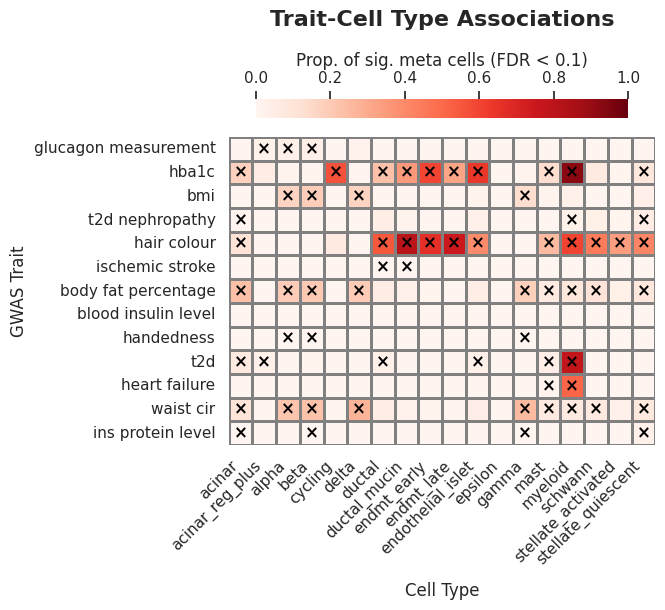

In [97]:
import seaborn as sns
df_prop_t = df_prop.T
df_sig_t = df_sig.T

plt.figure(figsize=(12, 5))
sns.set_theme(style="white")

ax = sns.heatmap(
    df_prop_t, 
    cmap="Reds", 
    linewidths=1, 
    linecolor='gray',
    square=True, 
    cbar_kws={
        "label": "Prop. of sig. meta cells (FDR < 0.1)", 
        "location": "top", 
        "shrink": .4,
        "pad": 0.05 
    },
    vmin=0, 
    vmax=1.0 
)

for i in range(len(df_prop_t.index)):      
    for j in range(len(df_prop_t.columns)):  
        if df_sig_t.iloc[i, j]:
            ax.text(j + 0.5, i + 0.5, '×', 
                    ha='center', va='center', 
                    color='black', fontsize=12, fontweight='bold')


plt.title("Trait-Cell Type Associations", pad=80, fontsize=16, fontweight='bold')
plt.xlabel("Cell Type", fontsize=12, labelpad=10)
plt.ylabel("GWAS Trait", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.show()